# The Asset Allocation Dilemma

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Temporary Workaround to read Google Sheets from MacOs
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Download Data

In [3]:
RESPONSES = 'https://docs.google.com/spreadsheets/d/1JLmaP93pouUq6ZerVA366hZRoDf05e13Pb-nomHklvQ/export?format=csv'

In [4]:
df = pd.read_csv(RESPONSES)
df.head()

,Timestamp,Email Address,Imagine you are given ₹1 Lakh today with one strict condition: \n\nYou must invest it and cannot touch it for 25 years. \n\nWhat % of this money would you allocate into Fixed Deposits ?
0,7/8/2026 10:12:58,brindadorairaj25@gmail.com,0.0
1,7/8/2026 10:13:10,brindadorairaj25@gmail.com,50.4
2,7/8/2026 10:13:20,brindadorairaj25@gmail.com,99.0


## Review Data

### How many respondents ?

In [5]:
df.index.size

3

In [6]:
df['Email Address'].nunique()

1

### What does your asset allocation look like ?

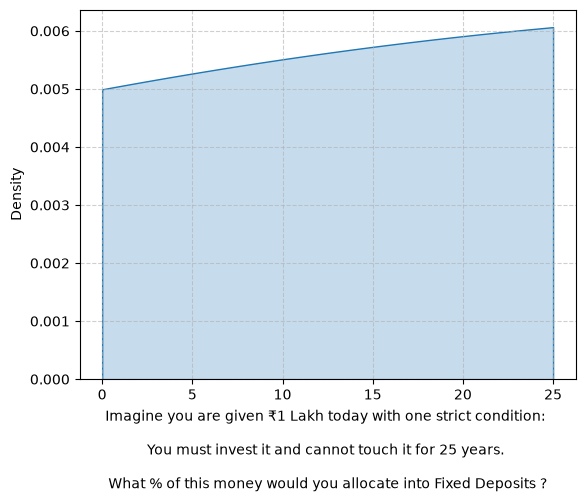

In [7]:
sns.kdeplot(df.iloc[:, 2], fill=True, clip=[0,25])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### What is the average allocation to FDs ?

In [48]:
df.iloc[:, 2].mean().item()

49.800000000000004

## How much does my money grow in 25 years ?

In [23]:
returns_df = pd.read_csv('./annual_returns.csv', index_col='year')
returns_df = 1 + returns_df/100
returns_df.loc[:, 'equity_cum'] = returns_df['equity'].cumprod()
returns_df.loc[:, 'fd_cum'] = returns_df['fd'].cumprod()
# returns_df

In [30]:
def invest(amount: float, pct_fd: float):
    portfolio_df = returns_df.copy()
    N = portfolio_df.index.size
    start_year = portfolio_df.index.min()

    frac_fd = pct_fd/100
    frac_equity = 1 - frac_fd

    value_equity = portfolio_df['equity_cum'] * frac_equity 
    value_fd = portfolio_df['fd_cum'] * frac_fd
    
    portfolio_df.loc[:, 'portfolio_value'] = value_equity + value_fd
    return portfolio_df['portfolio_value']

<Axes: xlabel='year', ylabel='portfolio_value'>

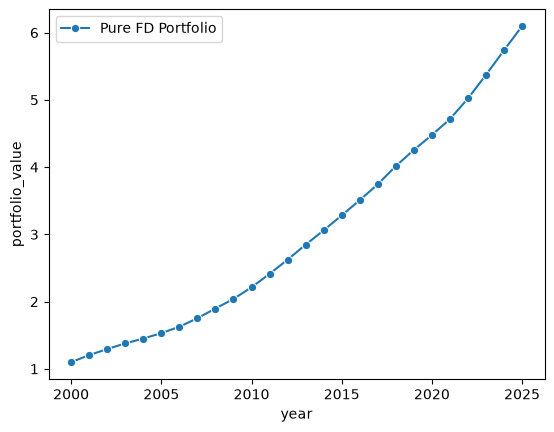

In [56]:
sns.lineplot(
    data=invest(amount=100000, pct_fd=100), label='Pure FD Portfolio', marker='o'  
)

# sns.lineplot(
#     data=invest(amount=100000, pct_fd=49.8), label='Class Average Portfolio', marker='s'  
# )

# sns.lineplot(
#     data=invest(amount=100000, pct_fd=0), label='Pure Equity Portfolio', marker='p'  
# )